In [2]:
!pip install pandas


Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install numpy matplotlib seaborn


Defaulting to user installation because normal site-packages is not writeable


In [7]:
import pandas as pd

df = pd.read_csv('C://Users//dell//Downloads//Titanic.csv')
df.head()
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sex       891 non-null    object 
 1   age       714 non-null    float64
 2   sibsp     891 non-null    int64  
 3   parch     891 non-null    int64  
 4   fare      891 non-null    float64
 5   embarked  889 non-null    object 
 6   class     891 non-null    object 
 7   who       891 non-null    object 
 8   alone     891 non-null    bool   
 9   survived  891 non-null    int64  
dtypes: bool(1), float64(2), int64(3), object(4)
memory usage: 63.6+ KB


sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
class         0
who           0
alone         0
survived      0
dtype: int64

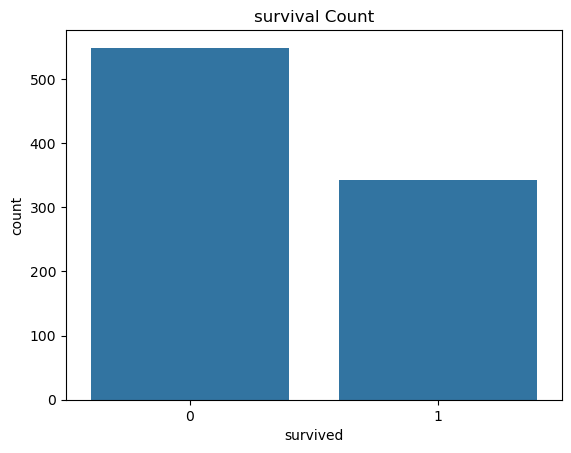

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='survived', data=df)
plt.title("survival Count")
plt.show()



number of fare outliers: 116


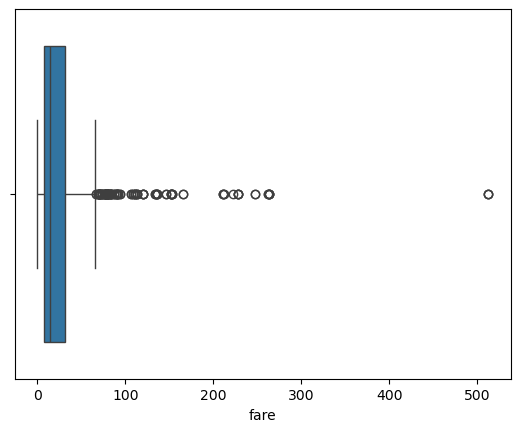

In [11]:
sns.boxplot(x=df['fare'])

Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['fare'] < Q1 - 1.5*IQR) | (df['fare'] > Q3 + 1.5*IQR)]
print("number of fare outliers:", len(outliers))


<Axes: xlabel='survived', ylabel='age'>

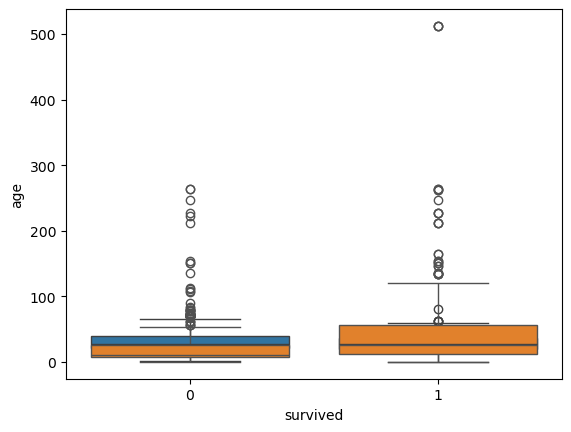

In [13]:
sns.boxplot(x='survived', y='age', data=df)
sns.boxplot(x='survived', y='fare', data=df)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')


In [9]:
df = pd.read_csv('C://Users//dell//Downloads//Titanic.csv')
df.head()


,sex,age,sibsp,parch,fare,embarked,class,who,alone,survived
0,male,22.0,1,0,7.2500,S,Third,man,False,0
1,female,38.0,1,0,71.2833,C,First,woman,False,1
2,female,26.0,0,0,7.9250,S,Third,woman,True,1
3,female,35.0,1,0,53.1000,S,First,woman,False,1
4,male,35.0,0,0,8.0500,S,Third,man,True,0


In [11]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sex       891 non-null    object 
 1   age       714 non-null    float64
 2   sibsp     891 non-null    int64  
 3   parch     891 non-null    int64  
 4   fare      891 non-null    float64
 5   embarked  889 non-null    object 
 6   class     891 non-null    object 
 7   who       891 non-null    object 
 8   alone     891 non-null    bool   
 9   survived  891 non-null    int64  
dtypes: bool(1), float64(2), int64(3), object(4)
memory usage: 63.6+ KB


sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
class         0
who           0
alone         0
survived      0
dtype: int64

In [28]:
print('class' in df.columns)  # Should be True


False


In [30]:
if 'class' in df.columns:
    df.drop(columns=['class'], inplace=True)
    print("Dropped column 'class'")
else:
    print("Still not found. Final column names are:", df.columns)


Still not found. Final column names are: Index(['sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'alone',
       'survived'],
      dtype='object')


In [32]:
df.columns = df.columns.str.strip()


In [34]:
print('class' in df.columns)  # Should now return True


False


In [36]:
print(list(df.columns))  # Shows column names clearly with any hidden characters


['sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'alone', 'survived']


In [38]:
for col in df.columns:
    print(f"'{col}'")


'sex'
'age'
'sibsp'
'parch'
'fare'
'embarked'
'who'
'alone'
'survived'


In [40]:
df.columns = df.columns.str.strip().str.lower()


In [46]:
df = pd.read_csv('C://Users//dell//Downloads//Titanic.csv', header=0)  # try this first
print(df.columns)


Index(['sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who',
       'alone', 'survived'],
      dtype='object')


In [68]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('C://Users//dell//Downloads//Titanic.csv')

# Fill missing values in 'age' column with the median age
if 'age' in df.columns:
    df['age'] = df['age'].fillna(df['age'].median())

# Fill missing values in 'embarked' column with the most frequent value (mode)
if 'embarked' in df.columns:
    df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
if 'class' in df.columns:
    df.drop(columns=['class'], inplace=True) 



ValueError: Could not interpret value `Pclass` for `x`. An entry with this name does not appear in `data`.

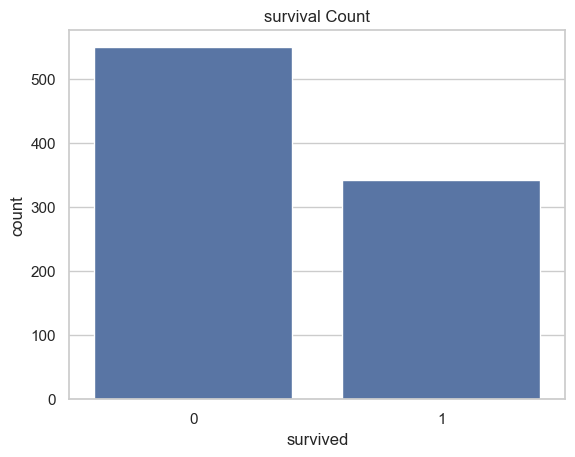

In [70]:
sns.countplot(x='survived', data=df)
plt.title('survival Count')

sns.countplot(x='Pclass', hue='survived', data=df)
plt.title('survival by Class')


<Axes: xlabel='survived', ylabel='age'>

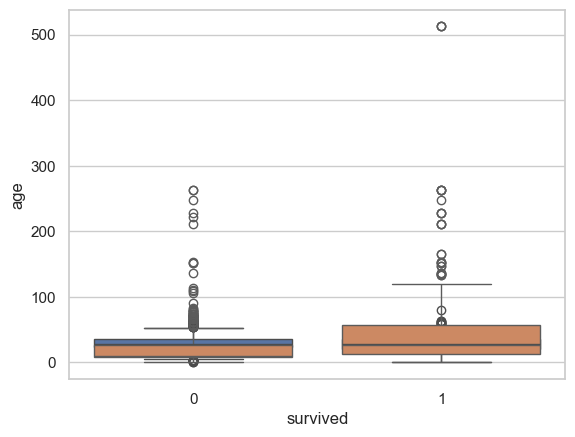

In [72]:
sns.boxplot(x='survived', y='age', data=df)
sns.boxplot(x='survived', y='fare', data=df)


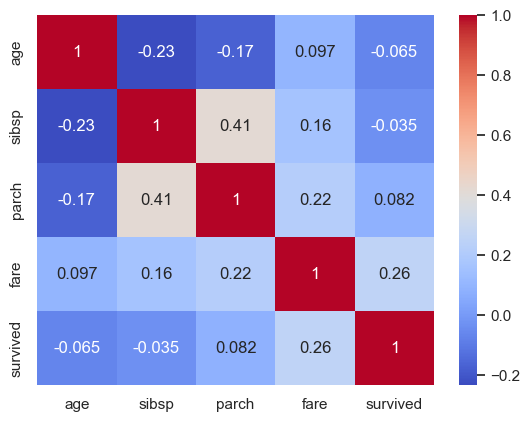

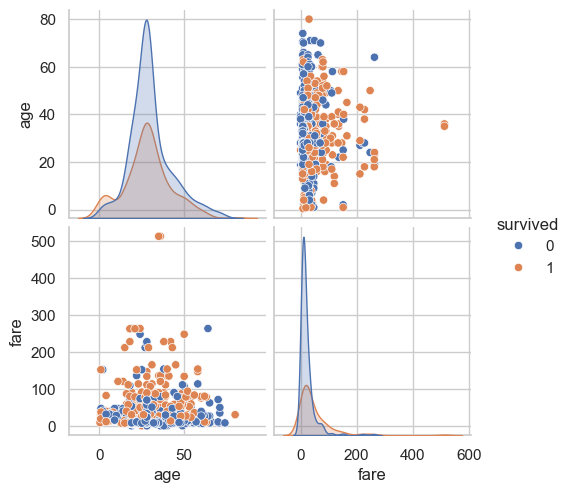

In [78]:
# First, check which columns are numeric
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# For the heatmap, use only numeric columns
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap='coolwarm')

# For the pairplot, ensure all columns are numeric
# If 'Survived' is already numeric (0 or 1), this should work
# Make sure 'Age' and 'Fare' are numeric columns
sns.pairplot(df[['age', 'fare', 'survived']], hue='survived')

# If you need to include categorical columns like gender, you should encode them first:
# df['Gender_encoded'] = df['Gender'].map({'male': 0, 'female': 1})
# Then use the encoded version in your visualizations